In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Ustawienie stylu wykresów (ładniej wyglądają w notatniku)
sns.set_theme(style="whitegrid")

In [38]:
# Wczytanie danych (upewnij się, że nazwa pliku jest poprawna)
df = pd.read_csv('ankieta_chor.csv')

# Wyświetlenie 5 pierwszych wierszy
print(f"Liczba wierszy przed czyszczeniem: {len(df)}")
df.head()

Liczba wierszy przed czyszczeniem: 95


,Sygnatura czasowa,Dyrygent ogłasza 10 minut przerwy. Twój standardowy ruch to:,Dyrygent przerywa i mówi: 'Ten fragment brzmi fatalnie w waszym głosie'. Co myślisz?\n,Poziom tremy przed wejściem na scenę:\n,Jaki jest Twój kolor włosów?,"Jak często zdarza Ci się rozmawiać z sąsiadem, gdy dyrygent ćwiczy z innym głosem?"" (Skala 1-10) \n",Strategia w przypadku pomyłki na koncercie:\n,Który opis punktualność Cię najbardziej opisuje:,Jak oceniasz proporcje swojej szyi? (Skala 1-10),Wzrost (w cm):,Co kosztuje Cię więcej fizycznego wysiłku podczas śpiewania?,"Kiedy cały chór śpiewa bardzo głośno (tutti), jak zazwyczaj odczuwasz swój własny głos na tle grupy?",Jakim głosem jesteś:
0,2026-06-04 16:46:21,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Analizuję technicznie, co dokładnie robimy źle.","Motywujący (lekki dreszczyk emocji, który poma...",Brązowe / Szatyn,6,Śpiewam ciszej i próbuję płynnie wrócić.,Zawsze 5 minut przed czasem,4.0,186.0,"Wejście bardzo wysoko (głos się zaciska, wymag...","Zawsze wyraźnie słyszę swój głos, ""przebija si...",Bas (bas 2)
1,2026-06-04 16:48:04,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Ja śpiewam dobrze, to reszta psuje.","Zerowy (pełen luz, traktuję to rutynowo).",Brązowe / Szatyn,1,"Uśmiecham się szeroko i udaję, że tak miało być.",Zawsze 5 minut przed czasem,6.0,159.0,"Zejście bardzo nisko (głos traci moc, matowieje).","Często w ogóle siebie nie słyszę, zagłuszają m...",Alt 1
2,2026-06-04 17:06:27,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Muszę się bardziej skupić, to pewnie też moja ...","Motywujący (lekki dreszczyk emocji, który poma...",Brązowe / Szatyn,6,Śpiewam ciszej i próbuję płynnie wrócić.,Zawsze 5 minut przed czasem,8.0,170.0,"Wejście bardzo wysoko (głos się zaciska, wymag...",Mój głos łatwo wtapia się w brzmienie reszty c...,Baryton (bas 1)
3,2026-06-04 17:11:40,Wychodzę na zewnątrz / idę coś zjeść lub się n...,"Muszę się bardziej skupić, to pewnie też moja ...","Motywujący (lekki dreszczyk emocji, który poma...",Brązowe / Szatyn,5,"Uśmiecham się szeroko i udaję, że tak miało być.",kilka minutek nikogo nigdy nie zbawił,6.0,170.0,"Wejście bardzo wysoko (głos się zaciska, wymag...","Zawsze wyraźnie słyszę swój głos, ""przebija si...",Sopran 2
4,2026-06-04 17:11:43,Idę pogadać z ludźmi z innych sekcji.,"Nic nie myślę, po prostu czekam, aż zaczniemy ...",Paraliżujący (zawsze bardzo się denerwuję).,Blond / Jasne,2,Śpiewam ciszej i próbuję płynnie wrócić.,Studencki kwadrans spóźnienia,8.0,176.0,"Wejście bardzo wysoko (głos się zaciska, wymag...","Często w ogóle siebie nie słyszę, zagłuszają m...",Sopran 2


In [39]:
 # 1. Zmiana nazw kolumn na krótkie i wygodne w kodzie

df.columns = [

    'Czas', 'Przerwa', 'Krytyka', 'Trema', 'Wlosy',

    'Gadatliwosc', 'Pomylka', 'Punktualnosc', 'Szyja',

    'Wzrost', 'Wysilek', 'Tutti', 'Glos'

]


# 2. Usunięcie szumu (czasu) i braków danych

df = df.drop('Czas', axis=1)

df = df.dropna()


# 3. Agregacja z 8 na 4 sekcje

voice_mapping = {

    'Sopran 1': 'Sopran', 'Sopran 2': 'Sopran',

    'Alt 1': 'Alt', 'Alt 2': 'Alt',

    'Tenor 1': 'Tenor', 'Tenor 2': 'Tenor',

    'Baryton (bas 1)': 'Bas', 'Bas (bas 2)': 'Bas'

}

df['Klasa'] = df['Glos'].map(voice_mapping)

df = df.dropna(subset=['Klasa']) # Usunięcie literówek, jeśli ktoś wpisał coś dziwnego

df = df.drop('Glos', axis=1)


# 4. Podział na X i y oraz One-Hot Encoding

y = df['Klasa']

X_raw = df.drop('Klasa', axis=1)


# Zamiana na 0 i 1

X = pd.get_dummies(X_raw, drop_first=True)


print(f"Dane gotowe! Zostało {X.shape[0]} kompletnych ankiet.")

print(f"Wygenerowano {X.shape[1]} cech.")


# Sprawdźmy, jak wyglądają dane gotowe dla modeli:

X.head() 

Dane gotowe! Zostało 92 kompletnych ankiet.
Wygenerowano 25 cech.


,Gadatliwosc,Szyja,Wzrost,Przerwa_Wychodzę na zewnątrz / idę coś zjeść lub się napić.,"Przerwa_Zostaję na miejscu, wyciągam telefon / odpoczywam w ciszy.",Przerwa_Zostaję w swojej sekcji i dyskutujemy/śmieszkujemy.,"Krytyka_Ja śpiewam dobrze, to reszta psuje.","Krytyka_Muszę się bardziej skupić, to pewnie też moja wina.","Krytyka_Nic nie myślę, po prostu czekam, aż zaczniemy znowu.",Trema_Paraliżujący (zawsze bardzo się denerwuję).,...,"Pomylka_Uśmiecham się szeroko i udaję, że tak miało być.",Pomylka_Śpiewam ciszej i próbuję płynnie wrócić.,Punktualnosc_Studencki kwadrans spóźnienia,Punktualnosc_Zawsze 15 minut przed czasem,Punktualnosc_Zawsze 5 minut przed czasem,Punktualnosc_kilka minutek nikogo nigdy nie zbawił,"Wysilek_Wejście bardzo wysoko (głos się zaciska, wymaga dużej siły).","Wysilek_Zejście bardzo nisko (głos traci moc, matowieje).",Tutti_Mój głos łatwo wtapia się w brzmienie reszty chóru (tzw. blendowanie).,"Tutti_Zawsze wyraźnie słyszę swój głos, ""przebija się"" przez inne."
0,6,4.0,186.0,True,False,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,1,6.0,159.0,True,False,False,True,False,False,False,...,True,False,False,False,True,False,False,True,False,False
2,6,8.0,170.0,True,False,False,False,True,False,False,...,False,True,False,False,True,False,True,False,True,False
3,5,6.0,170.0,True,False,False,False,True,False,False,...,True,False,False,False,False,True,True,False,False,True
4,2,8.0,176.0,False,False,False,False,False,True,True,...,False,True,True,False,False,False,True,False,False,False


In [40]:
# Definiujemy modele z włączonym balansem klas (class_weight='balanced')
models = {
    "Drzewo Decyzyjne": DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    "Las Losowy": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    "SVM (Liniowy)": SVC(class_weight='balanced', kernel='linear', random_state=42)
}

# 5-krotna walidacja krzyżowa (dba o zachowanie proporcji płci)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- ŚREDNIE WYNIKI Z 5-KROTNEJ WALIDACJI KRZYŻOWEJ ---\n")

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=['accuracy', 'f1_macro'])
    
    acc = scores['test_accuracy'].mean()
    acc_std = scores['test_accuracy'].std()
    
    f1 = scores['test_f1_macro'].mean()
    f1_std = scores['test_f1_macro'].std()
    
    print(f"🔥 {name}:")
    print(f"   Accuracy: {acc:.3f} (± {acc_std:.3f})")
    print(f"   F1-Macro: {f1:.3f} (± {f1_std:.3f})\n")

--- ŚREDNIE WYNIKI Z 5-KROTNEJ WALIDACJI KRZYŻOWEJ ---

🔥 Drzewo Decyzyjne:
   Accuracy: 0.401 (± 0.104)
   F1-Macro: 0.346 (± 0.095)

🔥 Las Losowy:
   Accuracy: 0.510 (± 0.081)
   F1-Macro: 0.452 (± 0.091)

🔥 SVM (Liniowy):
   Accuracy: 0.476 (± 0.105)
   F1-Macro: 0.414 (± 0.102)



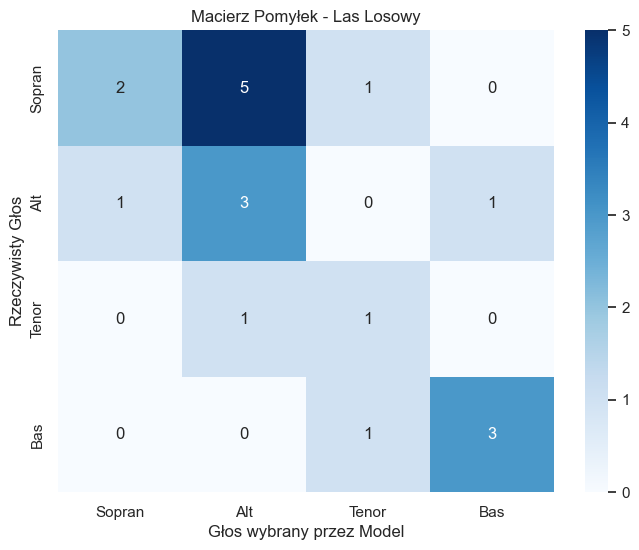


Raport Klasyfikacji:
              precision    recall  f1-score   support

         Alt       0.33      0.60      0.43         5
         Bas       0.75      0.75      0.75         4
      Sopran       0.67      0.25      0.36         8
       Tenor       0.33      0.50      0.40         2

    accuracy                           0.47        19
   macro avg       0.52      0.53      0.49        19
weighted avg       0.56      0.47      0.47        19



In [41]:
# Wydzielenie 20% danych na test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Trenowanie Lasu Losowego
best_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# Predykcja
y_pred = best_model.predict(X_test)

# Rysowanie macierzy pomyłek
cm = confusion_matrix(y_test, y_pred, labels=['Sopran', 'Alt', 'Tenor', 'Bas'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sopran', 'Alt', 'Tenor', 'Bas'], 
            yticklabels=['Sopran', 'Alt', 'Tenor', 'Bas'])
plt.ylabel('Rzeczywisty Głos')
plt.xlabel('Głos wybrany przez Model')
plt.title('Macierz Pomyłek - Las Losowy')
plt.show()

# Dokładny raport tekstowy
print("\nRaport Klasyfikacji:")
print(classification_report(y_test, y_pred))

C:\Users\macie\AppData\Local\Temp\ipykernel_4372\2731657522.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ważność', y='Cecha', data=top_10_features, palette='viridis')


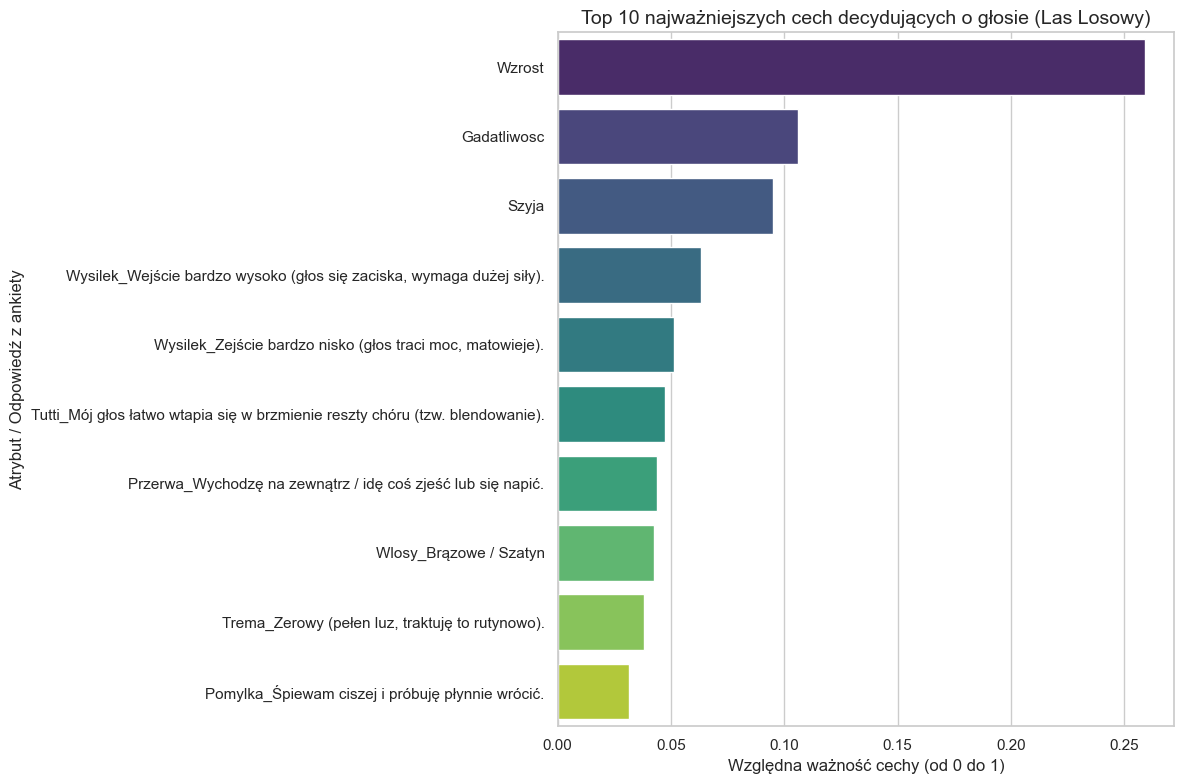

Dokładne wartości liczbowe dla Top 10 cech:
                                                                       Cecha  Ważność
                                                                      Wzrost 0.258981
                                                                 Gadatliwosc 0.105903
                                                                       Szyja 0.095133
        Wysilek_Wejście bardzo wysoko (głos się zaciska, wymaga dużej siły). 0.063167
                   Wysilek_Zejście bardzo nisko (głos traci moc, matowieje). 0.051282
Tutti_Mój głos łatwo wtapia się w brzmienie reszty chóru (tzw. blendowanie). 0.047130
                 Przerwa_Wychodzę na zewnątrz / idę coś zjeść lub się napić. 0.043764
                                                      Wlosy_Brązowe / Szatyn 0.042459
                             Trema_Zerowy (pełen luz, traktuję to rutynowo). 0.037998
                            Pomylka_Śpiewam ciszej i próbuję płynnie wrócić. 0.031522


In [42]:
# Pobranie wag (ważności) cech z wytrenowanego Lasu Losowego
importances = best_model.feature_importances_

# Stworzenie przejrzystej tabeli (DataFrame) z nazwami cech i ich wartościami
feature_names = X_train.columns
feature_imp_df = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
})

# Posortowanie tabeli malejąco (od najważniejszych do najmniej ważnych)
feature_imp_df = feature_imp_df.sort_values(by='Ważność', ascending=False)

# Wybór 10 najważniejszych cech, żeby wykres był czytelny
top_10_features = feature_imp_df.head(10)

# Rysowanie poziomego wykresu słupkowego
plt.figure(figsize=(12, 8))
sns.barplot(x='Ważność', y='Cecha', data=top_10_features, palette='viridis')

plt.title('Top 10 najważniejszych cech decydujących o głosie (Las Losowy)', fontsize=14)
plt.xlabel('Względna ważność cechy (od 0 do 1)', fontsize=12)
plt.ylabel('Atrybut / Odpowiedź z ankiety', fontsize=12)

# Funkcja tight_layout() dba o to, żeby długie teksty z ankiety nie zostały ucięte na brzegach
plt.tight_layout()
plt.show()

# Wyświetlenie dokładnych wartości liczbowych pod wykresem
print("Dokładne wartości liczbowe dla Top 10 cech:")
print(top_10_features.to_string(index=False))

Generowanie automatycznego raportu wizualnego...

Generuję wykres dla cechy: Wzrost...

Generuję wykres dla cechy: Gadatliwosc...

Generuję wykres dla cechy: Szyja...

Generuję wykres dla cechy: Wysilek...

Generuję wykres dla cechy: Tutti...

Generuję wykres dla cechy: Przerwa...

Generuję wykres dla cechy: Wlosy...

Generuję wykres dla cechy: Trema...

Generuję wykres dla cechy: Pomylka...
Generowanie automatycznego raportu wizualnego...

Generuję wykres dla cechy: Wzrost...


C:\Users\macie\AppData\Local\Temp\ipykernel_4372\2073931883.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)


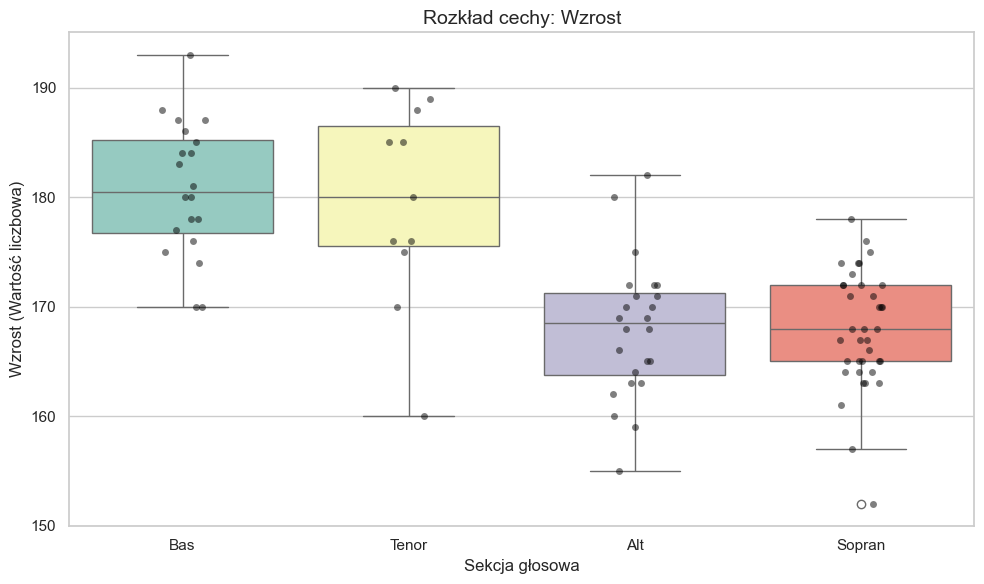


Generuję wykres dla cechy: Gadatliwosc...


C:\Users\macie\AppData\Local\Temp\ipykernel_4372\2073931883.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)


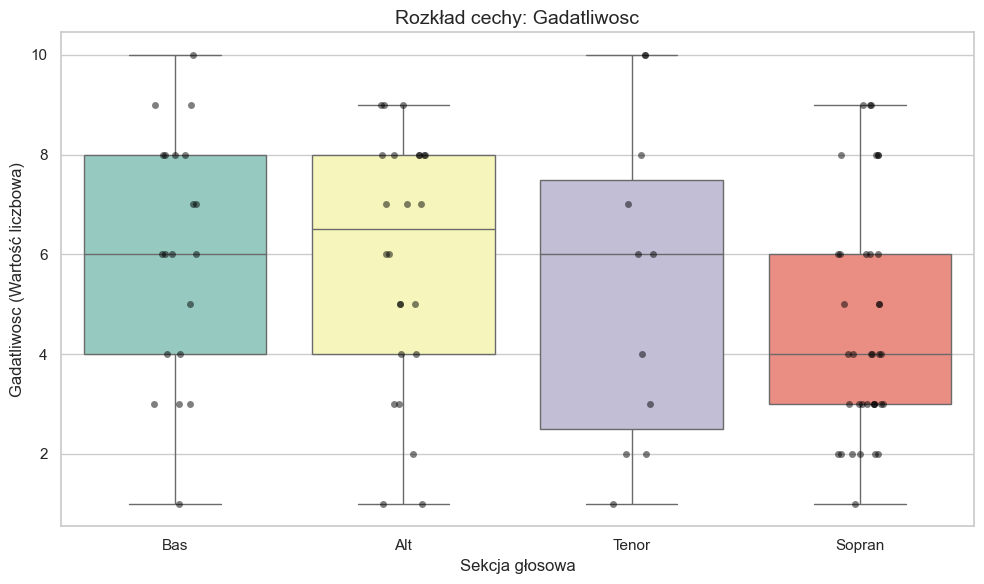


Generuję wykres dla cechy: Szyja...


C:\Users\macie\AppData\Local\Temp\ipykernel_4372\2073931883.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)


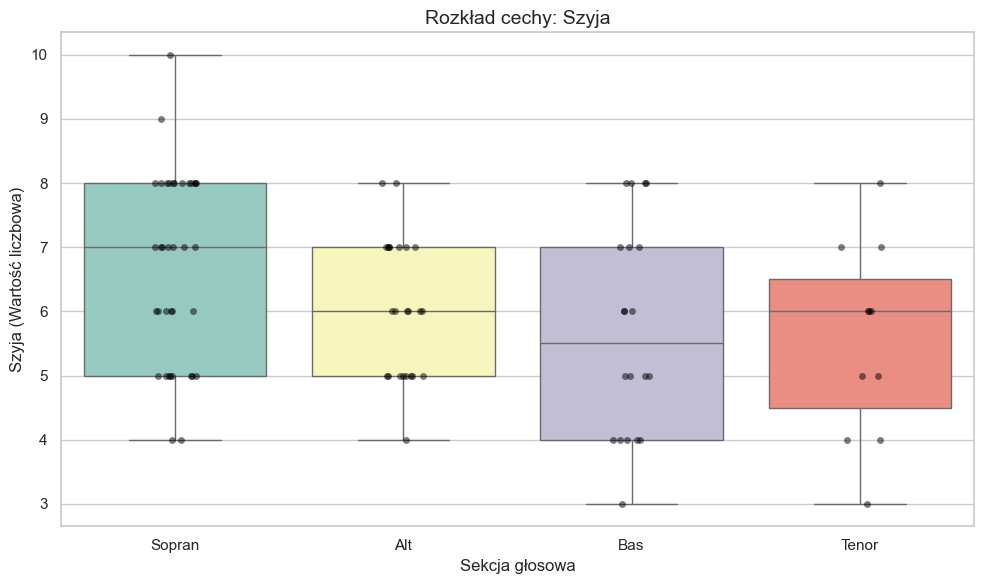


Generuję wykres dla cechy: Wysilek...


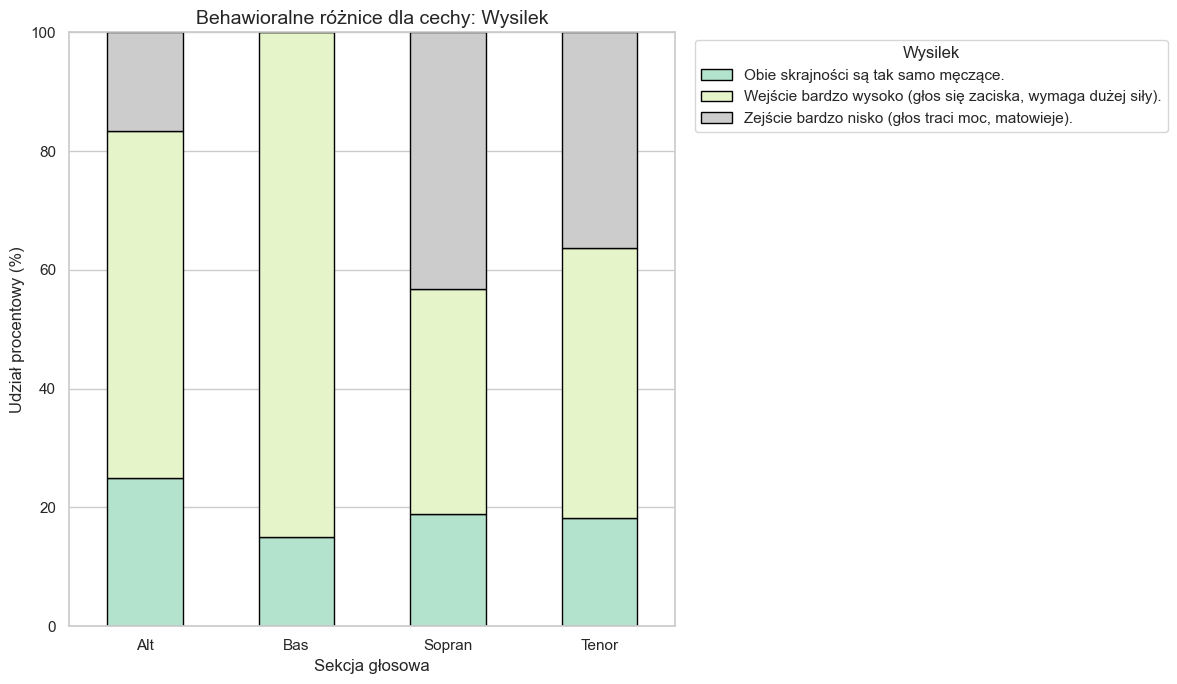


Generuję wykres dla cechy: Tutti...


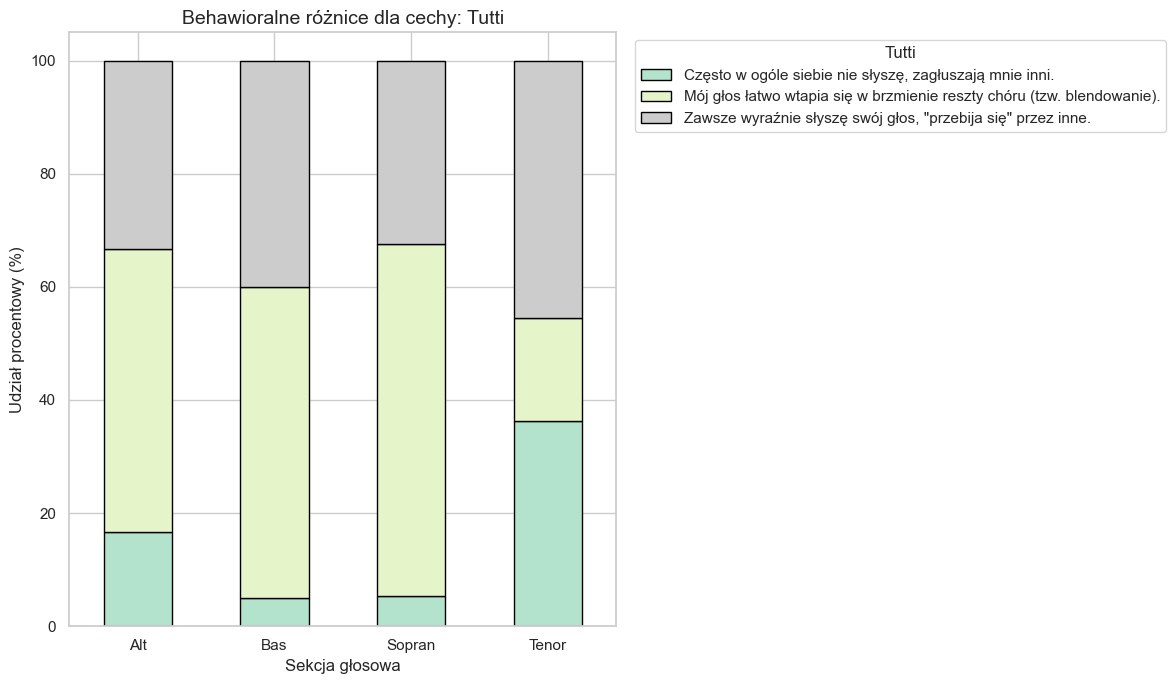


Generuję wykres dla cechy: Przerwa...


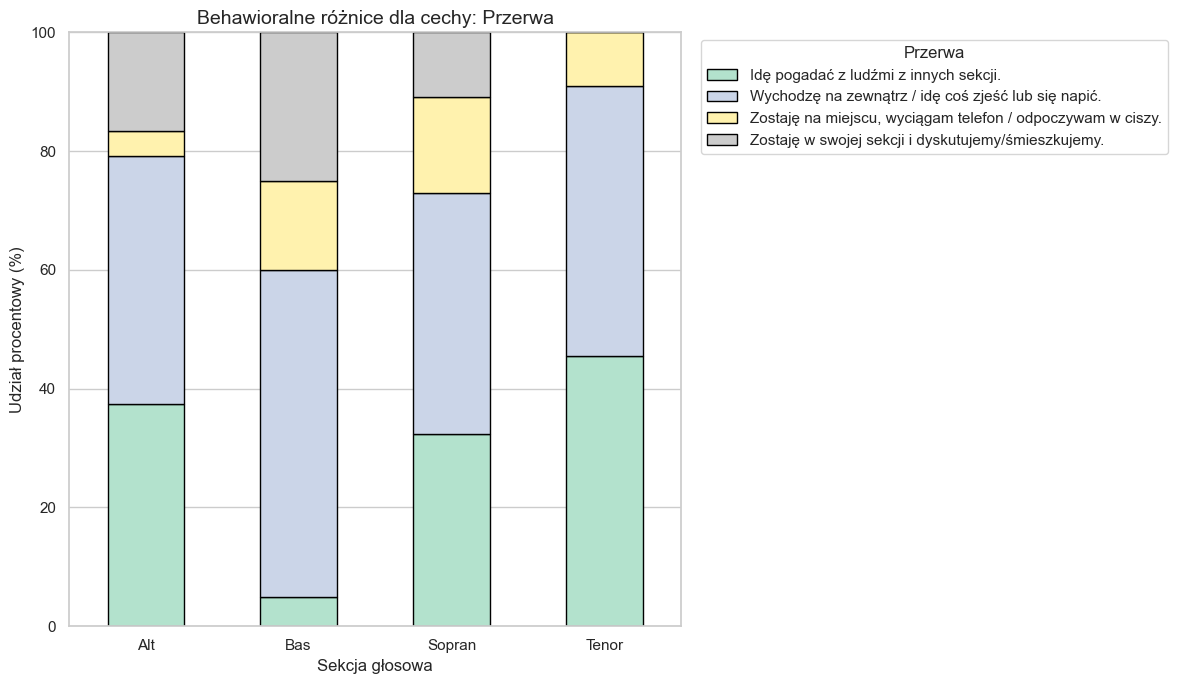


Generuję wykres dla cechy: Wlosy...


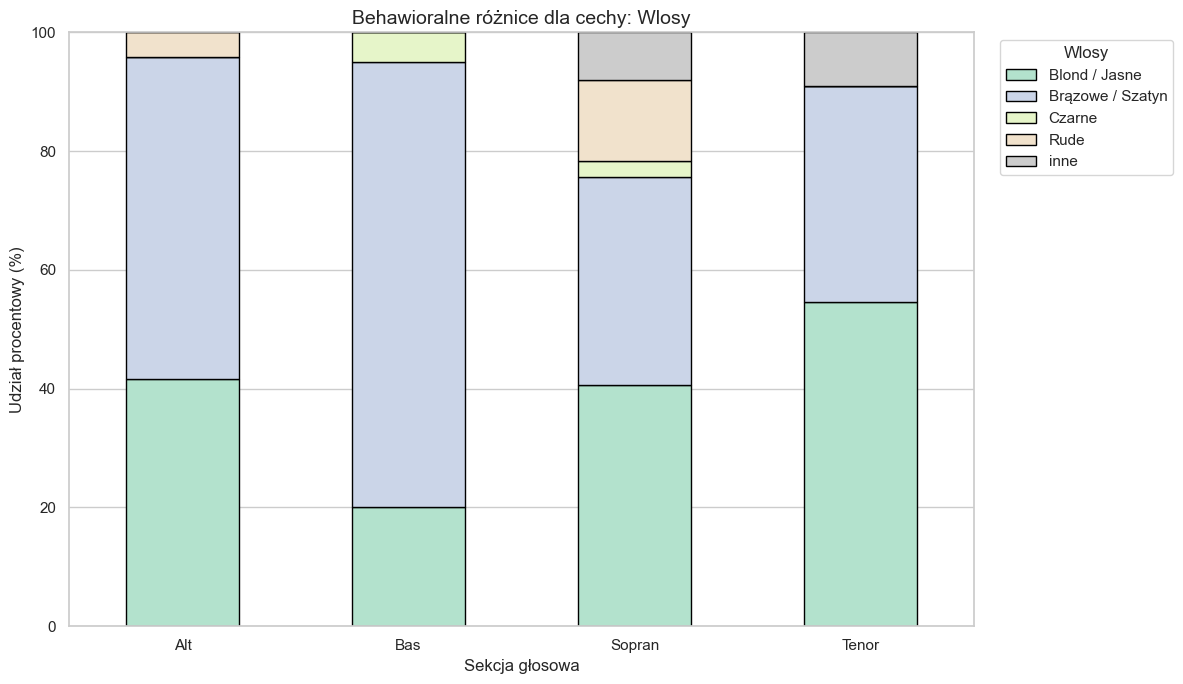


Generuję wykres dla cechy: Trema...


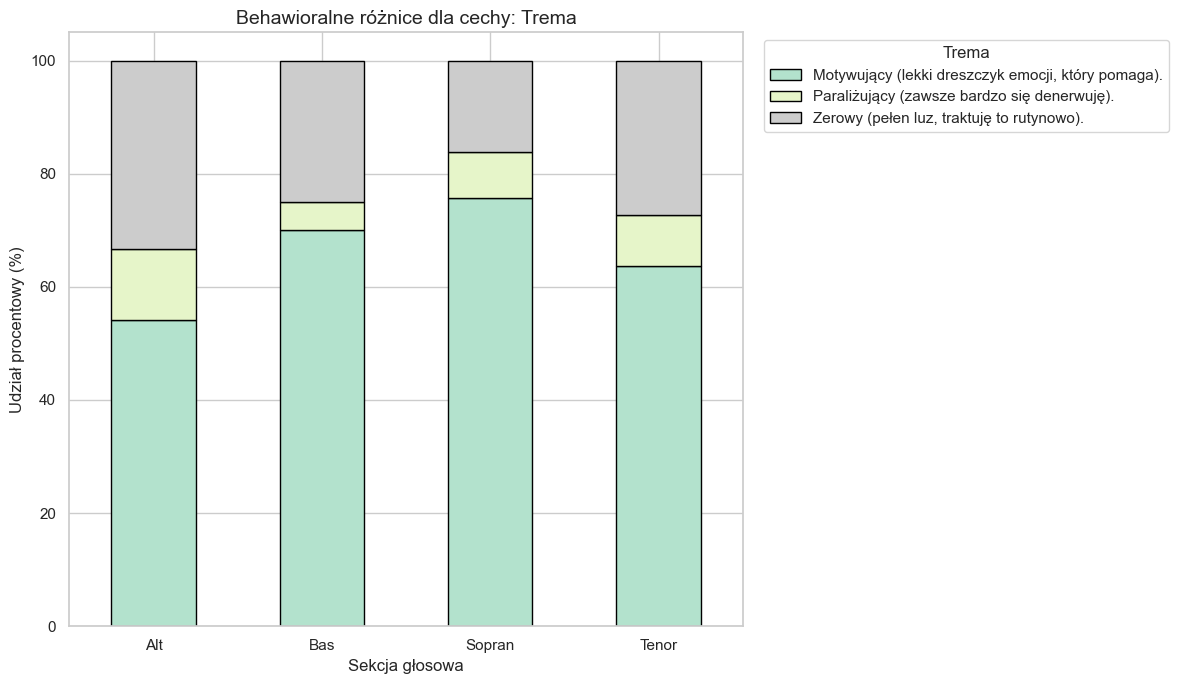


Generuję wykres dla cechy: Pomylka...


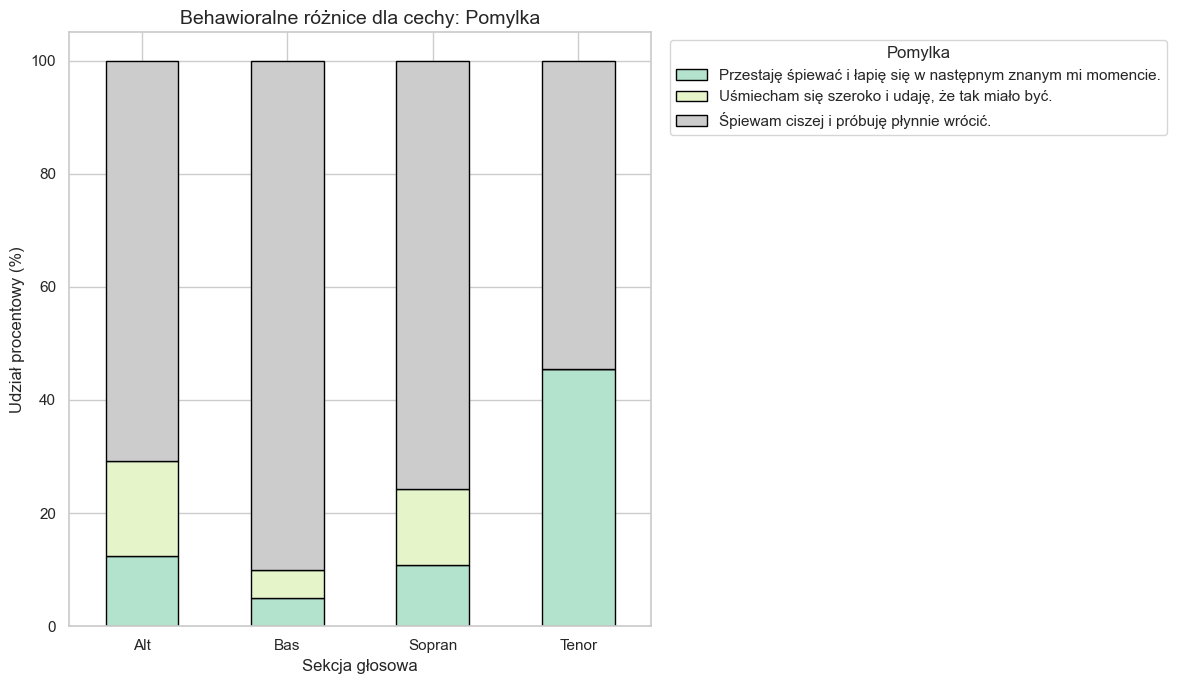


Koniec generowania! Wszystkie wykresy gotowe do pobrania do raportu.


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lista oryginalnych cech, które wygenerowały Twoje Top 10 wariantów w Lesie Losowym
top_cechy_oryginalne = [
    'Wzrost',      # Miejsce 1
    'Gadatliwosc', # Miejsce 2
    'Szyja',       # Miejsce 3
    'Wysilek',     # Miejsca 4 i 5
    'Tutti',       # Miejsce 6
    'Przerwa',     # Miejsce 7
    'Wlosy',       # Miejsce 8
    'Trema',       # Miejsce 9
    'Pomylka'      # Miejsce 10
]

print("Generowanie automatycznego raportu wizualnego...")
print("=" * 50)

for cecha in top_cechy_oryginalne:
    print(f"\nGeneruję wykres dla cechy: {cecha}...")
    
    # Automatyczne sprawdzanie typu danych w kolumnie
    if pd.api.types.is_numeric_dtype(df[cecha]):import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Lista oryginalnych cech, które wygenerowały Twoje Top 10 wariantów w Lesie Losowym
top_cechy_oryginalne = [
    'Wzrost',      # Miejsce 1
    'Gadatliwosc', # Miejsce 2
    'Szyja',       # Miejsce 3
    'Wysilek',     # Miejsca 4 i 5
    'Tutti',       # Miejsce 6
    'Przerwa',     # Miejsce 7
    'Wlosy',       # Miejsce 8
    'Trema',       # Miejsce 9
    'Pomylka'      # Miejsce 10
]

print("Generowanie automatycznego raportu wizualnego...")
print("=" * 50)

for cecha in top_cechy_oryginalne:
    print(f"\nGeneruję wykres dla cechy: {cecha}...")
    
    # Automatyczne sprawdzanie typu danych w kolumnie
    if pd.api.types.is_numeric_dtype(df[cecha]):
        
        # --- Ścieżka dla danych liczbowych: WYKRES PUDEŁKOWY ---
        plt.figure(figsize=(10, 6))
        
        # Wyliczamy średnie, żeby ładnie posortować pudełka
        srednie = df.groupby('Klasa')[cecha].mean().sort_values(ascending=False)
        
        sns.boxplot(x='Klasa', y=cecha, data=df, palette='Set3', order=srednie.index)
        sns.stripplot(x='Klasa', y=cecha, data=df, color='black', alpha=0.5, jitter=True, order=srednie.index)
        
        plt.title(f'Rozkład cechy: {cecha}', fontsize=14)
        plt.xlabel('Sekcja głosowa', fontsize=12)
        plt.ylabel(f'{cecha} (Wartość liczbowa)', fontsize=12)
        plt.tight_layout()
        plt.show()
        
    else:
        
        # --- Ścieżka dla danych tekstowych: WYKRES SKUMULOWANY 100% ---
        # Tworzymy tabelę procentową
        tabela = pd.crosstab(df['Klasa'], df[cecha], normalize='index') * 100
        
        ax = tabela.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='Pastel2', edgecolor='black')
        
        plt.title(f'Behawioralne różnice dla cechy: {cecha}', fontsize=14)
        plt.xlabel('Sekcja głosowa', fontsize=12)
        plt.ylabel('Udział procentowy (%)', fontsize=12)
        
        # Wyrzucenie legendy obok wykresu, żeby nie zasłaniała danych
        plt.legend(title=cecha, bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

print("\nKoniec generowania! Wszystkie wykresy gotowe do pobrania do raportu.")
        
        # --- Ś

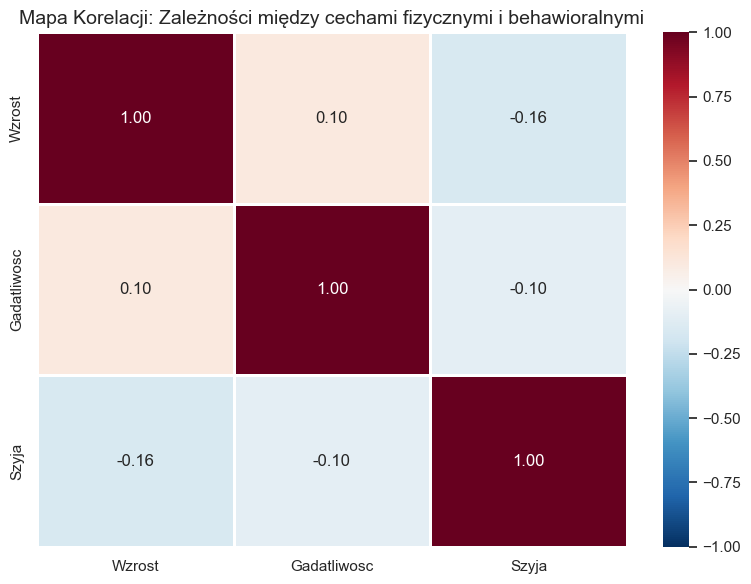

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wybieramy tylko kolumny liczbowe z oryginalnej ramki df
kolumny_liczbowe = ['Wzrost', 'Gadatliwosc', 'Szyja']
df_num = df[kolumny_liczbowe]

# Obliczanie macierzy korelacji (Pearson)
korelacje = df_num.corr()

plt.figure(figsize=(8, 6))
# Rysowanie heatmapy z paletą barw od czerwieni (ujemna korelacja) do zieleni (dodatnia)
sns.heatmap(korelacje, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, 
            fmt='.2f', linewidths=1, linecolor='white')

plt.title('Mapa Korelacji: Zależności między cechami fizycznymi i behawioralnymi', fontsize=14)
plt.tight_layout()
plt.show()

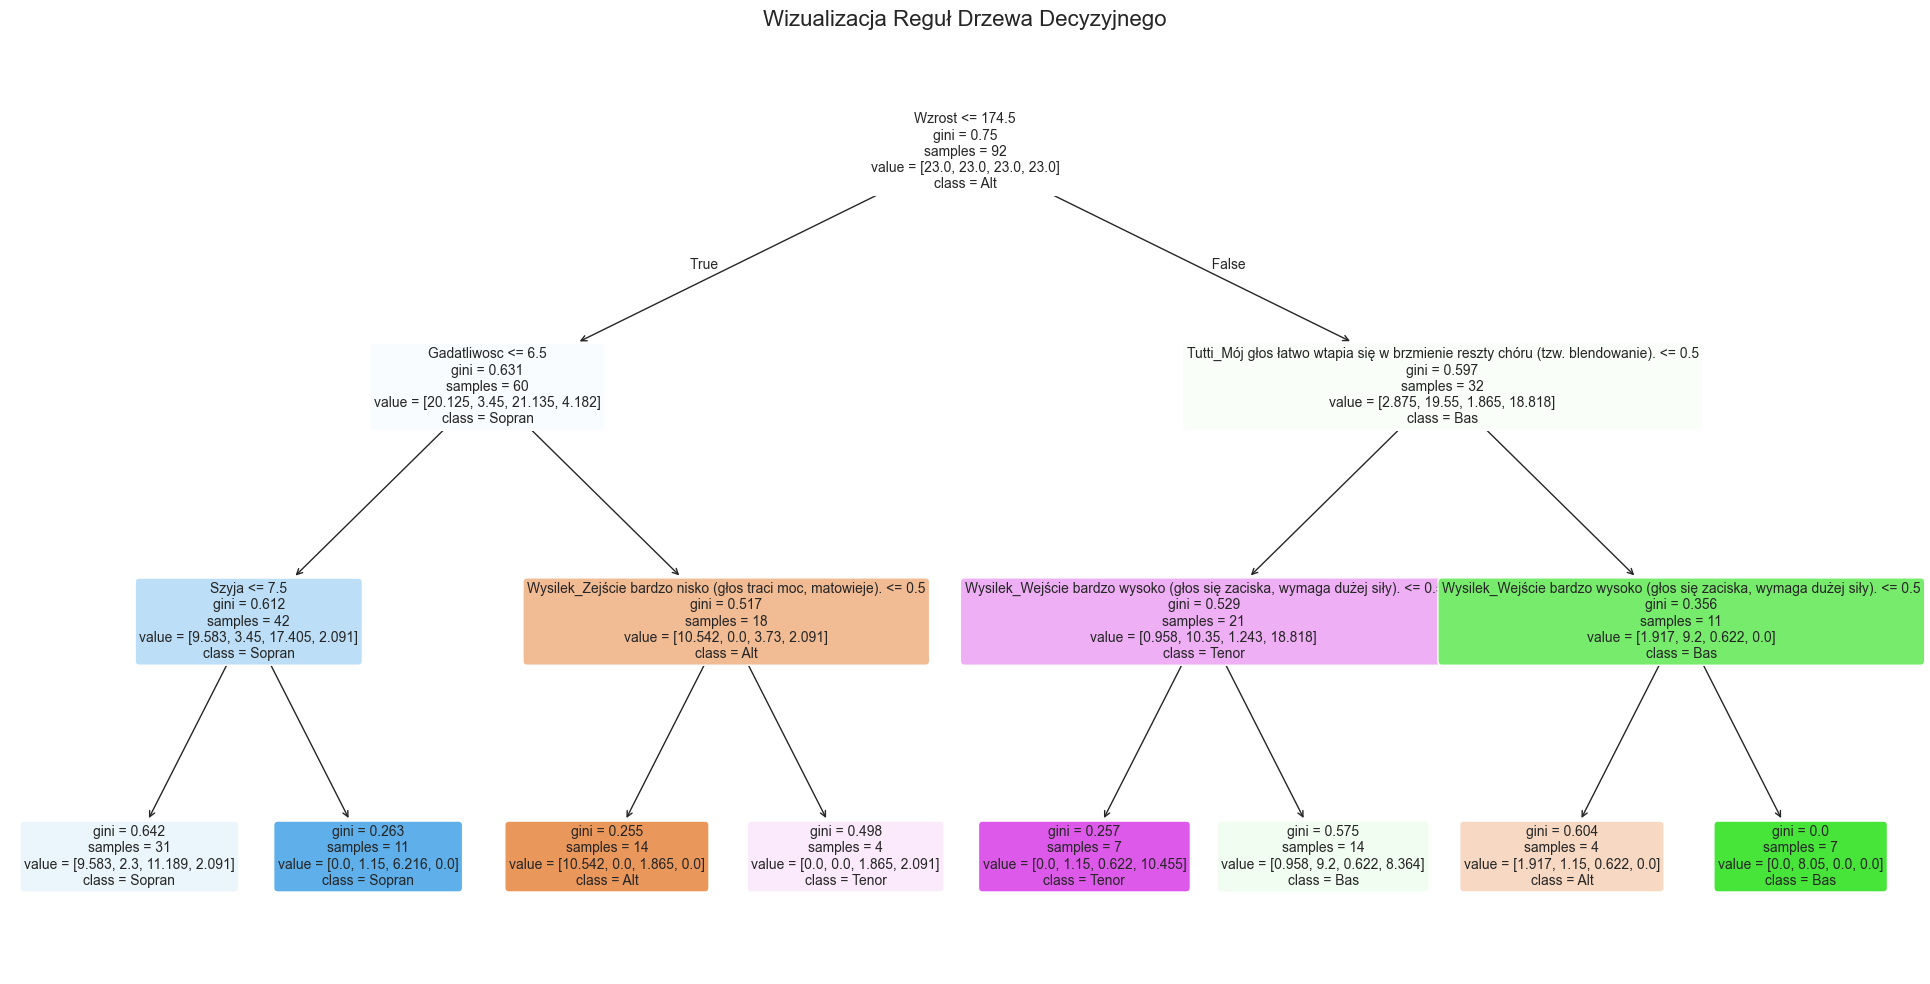

In [45]:
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Trenujemy jedno, proste drzewo na wszystkich danych (żeby ładnie wyglądało)
# Ustawiamy max_depth=3, żeby wykres nie był gigantyczny i nieczytelny
proste_drzewo = DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42)
proste_drzewo.fit(X, y)

plt.figure(figsize=(20, 10))
plot_tree(proste_drzewo, 
          feature_names=X.columns, 
          class_names=proste_drzewo.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title('Wizualizacja Reguł Drzewa Decyzyjnego', fontsize=16)
plt.tight_layout()
plt.show()